# Tarea 1

## 1. Considera el problema de Buffon presentado en clase y realiza lo siguiente:

### (a) Modifica el código visto en clase para que funcione para cualquier valor de $\textit{t}$. Verifica que tu código siga estimando a $π$ de manera adecuada.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

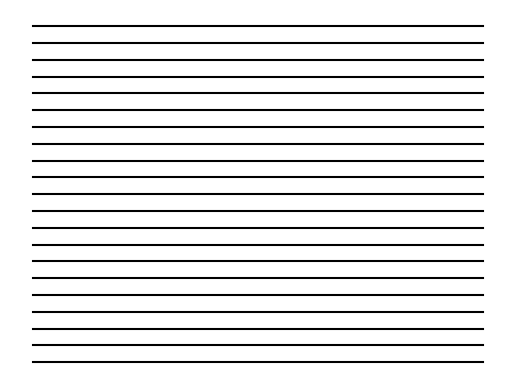

In [ ]:
n_strips = 20
w_strips = 2
l_needle = .5

g_x1 = np.zeros(n_strips + 1)
g_x2 = np.full(n_strips + 1, n_strips*w_strips)
g_y1 = np.arange(0, (n_strips + 1)*w_strips, w_strips)
g_y2 = g_y1.copy()

grid_lines = pd.DataFrame({'g_x1': g_x1, 'g_x2': g_x2, 'g_y1': g_y1, 'g_y2': g_y2})

fig, ax = plt.subplots()
for _, row in grid_lines.iterrows():
    ax.plot([row['g_x1'], row['g_x2']], [row['g_y1'], row['g_y2']], color='black')
ax.axis('off')
plt.show()

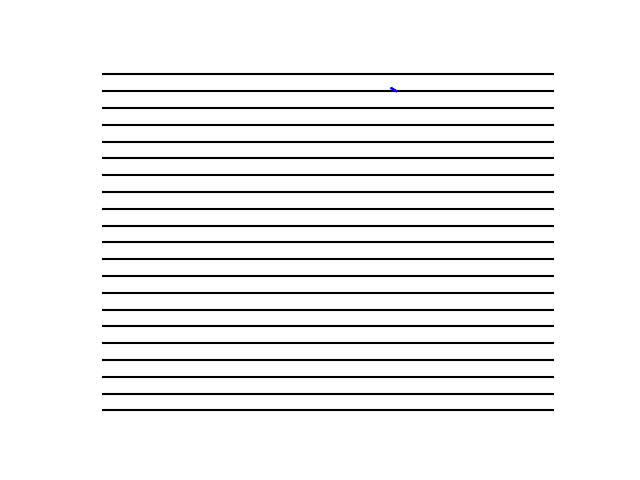

In [ ]:
n = 1000
np.random.seed(31415)
cx = np.random.uniform(0, n_strips*w_strips, n)
cy = np.random.uniform(0, n_strips*w_strips, n)
theta = np.random.uniform(0, np.pi, n)

n_x1 = cx - (l_needle / 2) * np.cos(theta)
n_y1 = cy - (l_needle / 2) * np.sin(theta)
n_x2 = cx + (l_needle / 2) * np.cos(theta)
n_y2 = cy + (l_needle / 2) * np.sin(theta)

crosses = np.floor(n_y1 / w_strips) != np.floor(n_y2 / w_strips)
needles = pd.DataFrame({
    'n_x1': n_x1, 'n_x2': n_x2,
    'n_y1': n_y1, 'n_y2': n_y2,
    'crosses': crosses
})
needles['throw'] = np.arange(1, n + 1)

fig, ax = plt.subplots()
ax.axis('off')
for _, row in grid_lines.iterrows():
    ax.plot([row['g_x1'], row['g_x2']], [row['g_y1'], row['g_y2']], color='black', zorder=1)

lines = []
def update(frame):
    row = needles.iloc[frame]
    color = 'red' if row['crosses'] else 'blue'
    line, = ax.plot([row['n_x1'], row['n_x2']], [row['n_y1'], row['n_y2']], color=color, zorder=2)
    lines.append(line)
    return lines

anim = FuncAnimation(fig, update, frames=n, interval=50, blit=True)
anim.save("BuffonsNeedle.gif", writer=PillowWriter(fps=50))
plt.close()
Image(filename="BuffonsNeedle.gif")

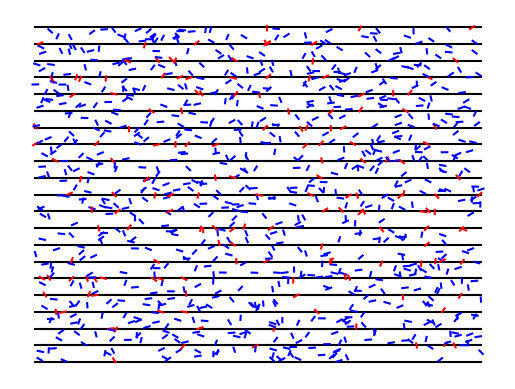

In [ ]:
fig, ax = plt.subplots()
ax.axis('off')
for _, row in grid_lines.iterrows():
    ax.plot([row['g_x1'], row['g_x2']], [row['g_y1'], row['g_y2']], color='black', zorder=1)
for _, row in needles.iterrows():
    color = 'red' if row['crosses'] else 'blue'
    ax.plot([row['n_x1'], row['n_x2']], [row['n_y1'], row['n_y2']], color=color, zorder=2)
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\h'
<>:10: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1871/3639410660.py:10: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('$\hat{P}$')


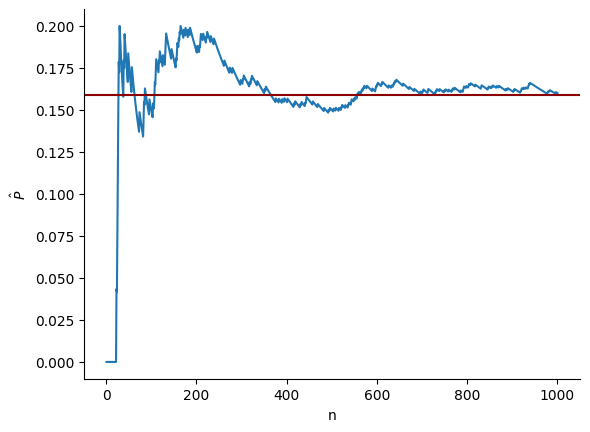

In [ ]:
n_seq = np.arange(1, n + 1)
p_hat_vals = np.cumsum(crosses) / n_seq
p_theoretical = 2 * l_needle / (np.pi * w_strips)
p_hat = pd.DataFrame({'x': n_seq, 'y': p_hat_vals})

fig, ax = plt.subplots()
ax.plot(p_hat['x'], p_hat['y'])
ax.axhline(y=p_theoretical, color='darkred')
ax.set_xlabel('n')
ax.set_ylabel('$\hat{P}$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1871/1239587165.py:8: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('$\hat{\pi}$')


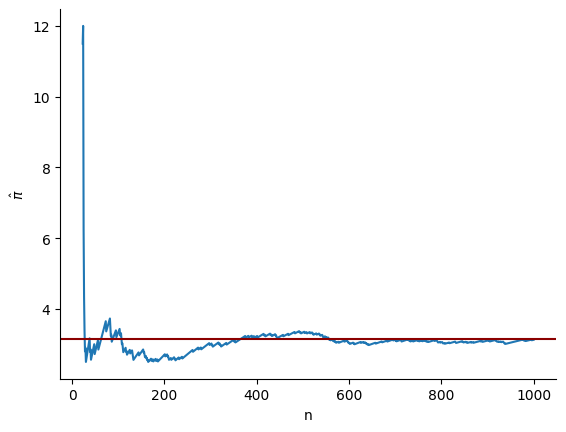

In [ ]:
pi_hat_vals = 2 * l_needle / (w_strips * p_hat['y'])
pi_hat = pd.DataFrame({'x': n_seq, 'y': pi_hat_vals})

fig, ax = plt.subplots()
ax.plot(pi_hat['x'], pi_hat['y'])
ax.axhline(y=np.pi, color='darkred')
ax.set_xlabel('n')
ax.set_ylabel('$\hat{\pi}$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### (b) Considera que la aguja tiene mayor tamaño que la separación entre líneas, esto es, $l > t$. ¿El código visto en clase sigue funcionando de manera adecuada?

No propiamente. Si bien, la simulación de los cruces de las agujas y las lineas funciona bien, el problema está en el calculo de la probabilidad. Esto explica porque al poner un valor $l>t$, la proba teorica, al igual que el valor calculado para $\pi$ dejan de ser correctos.

### (c) Obtén o consulta una expresión para la probabilidad de cruce cuando $l > t$, justifica la expresión utilizada y modifica el código para que funcione en ambos casos.

Para obtener la expresion usada en el caso $l<t$, utilizamos proba geometrica, donde primero consideramos nuetro espacio muestra. Todos centros de las agujas tienen que estar a una distancia de $0<y<\frac{t}{2}$ de alguna linea. Así mismo, $0<\theta<\pi$

Además el punto mas cercano de la aguja a la linea estará dado por $\frac{l}{2}sin(θ)$, por lo cual habrá un cruce cuando $y<\frac{l}{2}sin(θ)$. Así todos los casos en los que la aguja cruza estan descritos por
$$\int_0^{\pi} \frac{l}{2}sin(\theta) d\theta = \frac{l}{2} 2= l$$

Así es como obtenemos que $\mathbb{P}(\textit{Aguja cruce la linea}) = \frac{2l}{t\pi}$.

Ahora el problema cuando $l>t$ es que la curva $y = \frac{l}{2}sin(\theta)$ sale del rectangulo de nuestro espacio muestral, por lo cual tenemos sobre representados escenario.

La curva corta al limite cuando $\frac{l}{2}sin(\theta) = \frac{t}{2}$, ees decir, cuando $\theta=arcsin(\frac{t}{l})$. Además, como la curva es simetrica repecto a $\frac{\pi}{2}$, tenemos que los puntos de corte serán
$$\theta_0 = arcsin(\frac{t}{l})$$$$\theta_1 = \pi - arcsin(\frac{t}{l})$$
De esta manera el area bajo la curva dentro de los limites será
$$\int_0^{arcsin(\frac{t}{l})} \frac{l}{2}sin(\theta) d\theta+ (\pi - 2arcsin(\frac{t}{l}) + \int_{\pi - arcsin(\frac{t}{l})}^{\pi} \frac{l}{2}sin(\theta) d\theta$$
$$=l - \sqrt{l^{2}-t^{2}} +\frac{t\pi}{2} - t arcsin(\frac{t}{l})$$
Y la proba será
$$\mathbb{P}(\textit{Aguja cruce la linea}) = \frac{l - \sqrt{l^{2}-t^{2}} +\frac{t\pi}{2} - t arcsin(\frac{t}{l})}{\frac{\pi t}{2}} = $$
$$\frac{2l}{t\pi} - \frac{2}{\pi t} (\sqrt{l^{2}-t^{2}} + t arcsin(\frac{t}{l}))+1$$


In [ ]:
n = 10000
l_needle = 3
w_strips = 1
np.random.seed(31415)
cx = np.random.uniform(0, n_strips*w_strips, n)
cy = np.random.uniform(0, n_strips*w_strips, n)
theta = np.random.uniform(0, np.pi, n)

n_x1 = cx - (l_needle / 2) * np.cos(theta)
n_y1 = cy - (l_needle / 2) * np.sin(theta)
n_x2 = cx + (l_needle / 2) * np.cos(theta)
n_y2 = cy + (l_needle / 2) * np.sin(theta)

crosses = np.floor(n_y1 / w_strips) != np.floor(n_y2 / w_strips)
needles = pd.DataFrame({
    'n_x1': n_x1, 'n_x2': n_x2,
    'n_y1': n_y1, 'n_y2': n_y2,
    'crosses': crosses
})
needles['throw'] = np.arange(1, n + 1)

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1871/3934415433.py:11: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('$\hat{P}$')


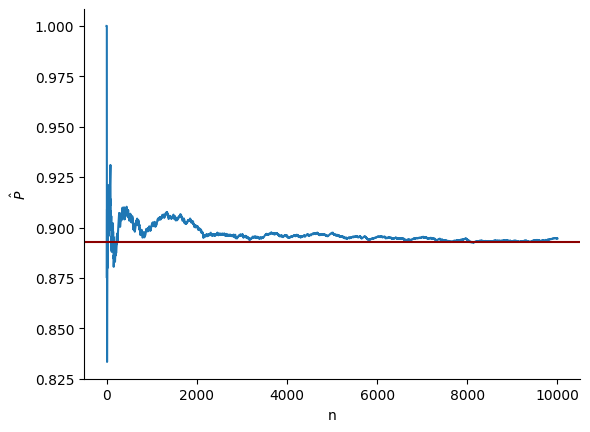

In [ ]:
n_seq = np.arange(1, n + 1)
p_hat_vals = np.cumsum(crosses) / n_seq
p_theoretical = 2 * l_needle / (np.pi * w_strips) - (2/(np.pi*w_strips))*(np.sqrt(l_needle**2-w_strips**2) +
                                                                          w_strips*np.arcsin(w_strips/l_needle)) + 1
p_hat = pd.DataFrame({'x': n_seq, 'y': p_hat_vals})

fig, ax = plt.subplots()
ax.plot(p_hat['x'], p_hat['y'])
ax.axhline(y=p_theoretical, color='darkred')
ax.set_xlabel('n')
ax.set_ylabel('$\hat{P}$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\h'
<>:8: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1871/785086641.py:8: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('$\hat{\pi}$')


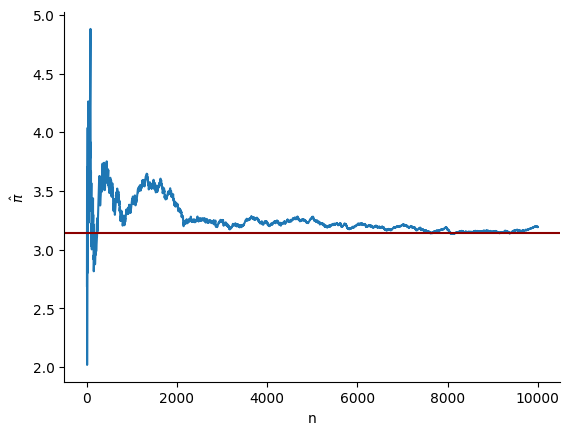

In [ ]:
pi_hat_vals = 2 * (l_needle-(np.sqrt(l_needle**2-w_strips**2)+ w_strips*np.arcsin(w_strips/l_needle))) / (w_strips * (p_hat['y'] - 1))
pi_hat = pd.DataFrame({'x': n_seq, 'y': pi_hat_vals})

fig, ax = plt.subplots()
ax.plot(pi_hat['x'], pi_hat['y'])
ax.axhline(y=np.pi, color='darkred')
ax.set_xlabel('n')
ax.set_ylabel('$\hat{\pi}$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

## 2. Otra manera de estimar a $π$ es considerando un círculo de radio $1$ incrustado en un cuadrado como el que se ve en la Figura 1.

### (a) ¿Cuál es la probabilidad de que un punto lanzado al azar caigo dentro del círculo?

Asumieno que los puntos se avientan de manera uniforme sobre todo el cuadrado, entonces este será un caso de probabilidad geometrica. En el cual nuestra probabilidad estará dada por casos favorables entre casos totales, así

$$\mathbb{P}(\textit{Caiga dentro del circulo}) = \frac{\mathbb{A}(Círculo)}{\mathbb{A}(Cuadrado)} = \frac{\pi}{4}$$

### (b) ¿Cómo puedes utilizar este resultado para aproximar a $π$? Escribe un programa en el lenguaje de tu preferencia que te permita aproximar a $π$ utilizando este método.

Podemos simular dos variables uniformes para obtener con cada una, una coordenada de nuestro punto, si la distancia de este punto al origen es menor o igual a $1$, entonces este estará dentro del circulo. De esta manera podemos obtener la probabilidad empirica, con la cual podemos igualarla a la probabilidad teórica, y así obtener nuestra aproximacion de $\pi$.

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1871/1324654259.py:17: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('$\hat{\pi}$')


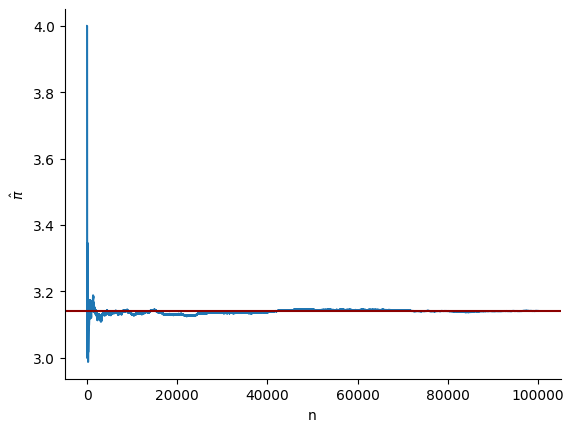

In [ ]:
n = 100000
n_seq = np.arange(1, n + 1)
np.random.seed(29)
cx = np.random.uniform(-1, 1, n)
cy = np.random.uniform(-1, 1, n)
dentro = (np.sqrt(cx**2 + cy**2) <= 1)

p_hat_vals = np.cumsum(dentro) / np.arange(1, n + 1)
pi_hat_vals = 4 * p_hat_vals

pi_hat = pd.DataFrame({'x': n_seq, 'y': pi_hat_vals})

fig, ax = plt.subplots()
ax.plot(pi_hat['x'], pi_hat['y'])
ax.axhline(y=np.pi, color='darkred')
ax.set_xlabel('n')
ax.set_ylabel('$\hat{\pi}$')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

### (c) Para $n = 100, 1000, 10000$ y $100000$, replica $100$ veces cada experimento y calcula el error cuadrático medio (ECM) de las aproximaciones obtenidas para ambos métodos. Grafica el ECM en función de $n$ y compara los resultados. ¿Cuál de los dos métodos parece ser más eficiente? Justifica tu respuesta.

In [ ]:
def calcular_ECM_1(l_needle, w_strips, n, random = 29, replica = 100):
    pi_hat_vals = np.zeros(replica)
    p_hat_vals = np.zeros(replica)
    if l_needle <= w_strips:
      for i in range(replica):
        np.random.seed(random + i)
        cx = np.random.uniform(0, n_strips*w_strips, n)
        cy = np.random.uniform(0, n_strips*w_strips, n)
        theta = np.random.uniform(0, np.pi, n)

        n_x1 = cx - (l_needle / 2) * np.cos(theta)
        n_y1 = cy - (l_needle / 2) * np.sin(theta)
        n_x2 = cx + (l_needle / 2) * np.cos(theta)
        n_y2 = cy + (l_needle / 2) * np.sin(theta)

        crosses = np.floor(n_y1 / w_strips) != np.floor(n_y2 / w_strips)
        n_seq = np.arange(1, n + 1)
        p_hat_vals[i] = np.sum(crosses) / n
        pi_hat_vals[i] = 2 * l_needle / (w_strips * p_hat_vals[i])
    else:
      for i in range(replica):
        np.random.seed(random + i)
        cx = np.random.uniform(0, n_strips*w_strips, n)
        cy = np.random.uniform(0, n_strips*w_strips, n)
        theta = np.random.uniform(0, np.pi, n)

        n_x1 = cx - (l_needle / 2) * np.cos(theta)
        n_y1 = cy - (l_needle / 2) * np.sin(theta)
        n_x2 = cx + (l_needle / 2) * np.cos(theta)
        n_y2 = cy + (l_needle / 2) * np.sin(theta)

        crosses = np.floor(n_y1 / w_strips) != np.floor(n_y2 / w_strips)
        n_seq = np.arange(1, n + 1)
        p_hat_vals[i] = np.sum(crosses) / n
        pi_hat_vals[i] = 2 * (l_needle-(np.sqrt(l_needle**2-w_strips**2)+
                                        w_strips*np.arcsin(w_strips/l_needle))) / (w_strips * (p_hat_vals[i] - 1))

    EMC = np.mean((pi_hat_vals - np.pi)**2)
    return EMC


In [ ]:
EMC_1 = []
X = [100, 1000, 10000, 100000]
for i in X:
  EMC_1.append(calcular_ECM_1(l_needle = .5, w_strips = 1, n = i))
print(EMC_1)

[np.float64(0.2783664451553523), np.float64(0.023353820020942093), np.float64(0.002148834512287131), np.float64(0.0002738729949713938)]


In [ ]:
def calcular_ECM_2(n, random = 29, replica = 100):
    pi_hat_vals = np.zeros(replica)
    p_hat_vals = np.zeros(replica)
    for i in range(replica):
      np.random.seed(random + i)
      cx = np.random.uniform(-1, 1, n)
      cy = np.random.uniform(-1, 1, n)
      dentro = (np.sqrt(cx**2 + cy**2) <= 1)
      p_hat_vals[i] = np.sum(dentro) / n
      pi_hat_vals[i] = 4 * p_hat_vals[i]
    EMC = np.mean((pi_hat_vals - np.pi)**2)
    return EMC

In [ ]:
EMC_2 = []
for i in X:
  EMC_2.append(calcular_ECM_2(n = i))
print(EMC_2)

[np.float64(0.02401358698217388), np.float64(0.0023210936068929974), np.float64(0.00024644790904039445), np.float64(2.6013601679512836e-05)]


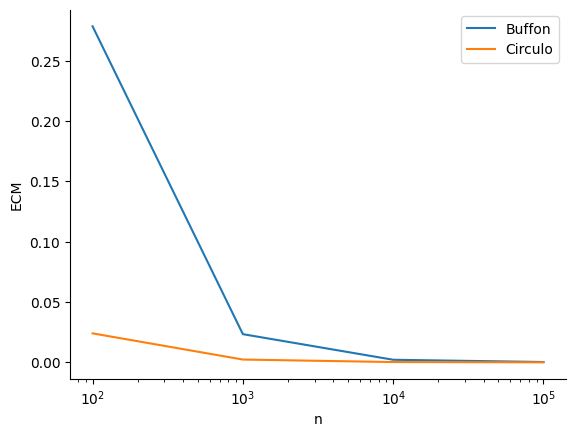

In [ ]:
fig, ax = plt.subplots()
ax.plot(X, EMC_1, label = 'Buffon')
ax.plot(X, EMC_2, label = 'Circulo')
ax.set_xlabel('n')
ax.set_ylabel('EMC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xscale('log')
ax.legend()
plt.show()

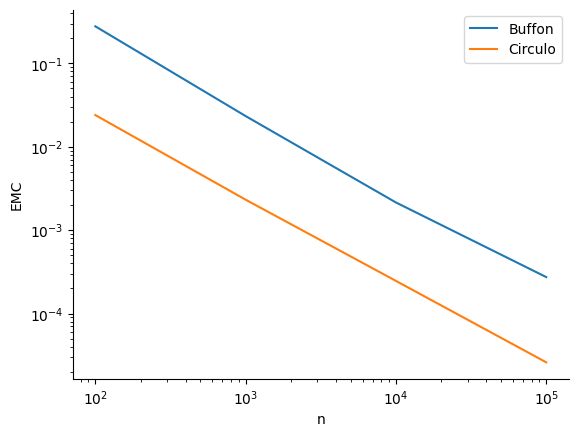

In [ ]:
fig, ax = plt.subplots()
ax.plot(X, EMC_1, label = 'Buffon')
ax.plot(X, EMC_2, label = 'Circulo')
ax.set_xlabel('n')
ax.set_ylabel('EMC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xscale('log')
plt.yscale('log')
ax.legend()
plt.show()

Pareciera que el método del círculo es mucho mas eficiente, en los datos lo podemos ver, ya que vemos que el valor del EMC para cada valor de n, suele ser 10 menor el del circulo que el de las agujas.

Así mismo en la gráfica podemos ver que al inicio es mayor el ECM y despues se van acercando mucho, hasta que pareciera que tienen el mismo valor. Eso es así ya que ambos van disminuyendo bastante hasta que en la gráfica se ven igual, pero sigue manteniendose casí 10 veces menor el valor del circulo.

En la otra gráfica podemos ver mejor, como se matiene esta proporcion casi constante para cada uno de los valores de n